# Part detection + damage demo

Run all three cells in the CRATER environment. This loads saved models and displays predictions; no training. Defaults are three images held out by both models. These shared examples mainly show intact parts. Colors: green = no visible damage, amber = possible damage, red = severe damage, gray = unobservable. Scores are model confidence, not calibrated reliability.


In [1]:
import json
import math
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "configs/taxonomy.json").is_file())
sys.path[:0] = [str(ROOT), str(ROOT / "third_party/YOLOX")]

import cv2
import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display
from yolox.data import ValTransform
from yolox.exp import get_exp
from yolox.utils import postprocess
from experiments.damage.training import build_model, DamageCrops
from tools.data.import_cvat_damage_annotations import PART_GROUPS, sha256_file

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DAMAGE_RUN = ROOT / "outputs/damage/humvee_cvat/humvee_damage_real_then_synthetic_v1"
DETECTOR_PATH = ROOT / "outputs/detection/humvee_source6/carparts_initialized_seed42/best_ckpt.pth"
annotations = json.loads((ROOT / "datasets/military/components/source/humvee/instances_default.json").read_text())
PARTS = [c["name"] for c in sorted(annotations["categories"], key=lambda c: c["id"])]
exp = get_exp(str(ROOT / "experiments/detection/yolox_s_crater6.py"), None)
assert len(PARTS) == exp.num_classes and set(PARTS) <= PART_GROUPS.keys()
detector = exp.get_model()
# This is the trusted local YOLOX training checkpoint.
detector.load_state_dict(torch.load(DETECTOR_PATH, map_location="cpu", weights_only=False)["model"])
detector.to(DEVICE).eval()
detector_transform = ValTransform(legacy=False)

damage_models, damage_transforms, damage_levels = {}, {}, {}
selection = json.loads((DAMAGE_RUN / "selected_checkpoints.json").read_text())
for group in sorted(set(PART_GROUPS.values())):
    record = selection[group]
    path = DAMAGE_RUN / record["path"].replace("\\", "/")
    assert sha256_file(path) == record["sha256"], f"Changed checkpoint: {path}"
    checkpoint = torch.load(path, map_location="cpu", weights_only=True)
    assert checkpoint["group"] == group
    levels = checkpoint["levels"]
    model = build_model(len(levels), initialization="scratch")
    model.load_state_dict(checkpoint["model"])
    damage_models[group] = model.to(DEVICE).eval()
    damage_transforms[group] = DamageCrops([], ROOT, levels, checkpoint["config"]["image_size"]).transform
    damage_levels[group] = levels
print(f"Ready on {DEVICE}; damage models: " + ", ".join(f"{g}={Path(r['path']).parent}" for g, r in selection.items()))

Ready on cuda; damage models: mobility=real\mobility, structure=real\structure, mission_equipment=real\mission_equipment


In [6]:
# Replace these paths to try your own images. Defaults are held out by both models.
IMAGE_PATHS = [
    ROOT / "datasets/military/components/source/humvee/commons_111156378.jpg",
    ROOT / "datasets/military/components/source/humvee/commons_116331332.jpg",
    ROOT / "datasets/military/components/source/humvee/commons_122203760.jpg",
]
DETECTION_THRESHOLD = 0.25
COLORS = {"no_visible_damage": "#229954", "possible_damage": "#d68910",
          "severe_visible_damage": "#c0392b", "unobservable": "#707b7c"}
SHORT_LABELS = {"no_visible_damage": "no damage", "possible_damage": "possible",
                "severe_visible_damage": "severe", "unobservable": "unobservable"}
try:
    font = ImageFont.truetype("arial.ttf", 14)
except OSError:
    font = ImageFont.load_default()

commons_111156378.jpg — 7 detected parts


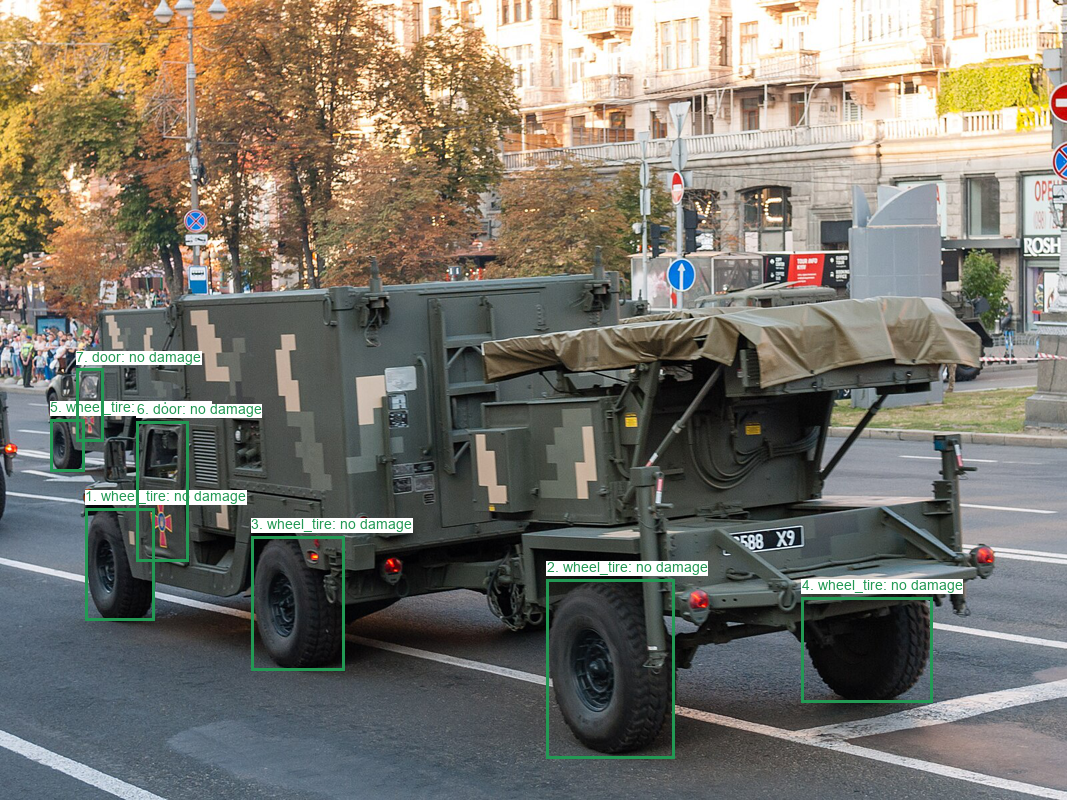

,part,damage,part score,damage score
box,,,,
1,wheel_tire,no_visible_damage,0.957,0.870
2,wheel_tire,no_visible_damage,0.955,0.596
3,wheel_tire,no_visible_damage,0.940,0.813
4,wheel_tire,no_visible_damage,0.939,0.727
5,wheel_tire,no_visible_damage,0.928,0.897
6,door,no_visible_damage,0.903,1.000
7,door,no_visible_damage,0.824,1.000


commons_116331332.jpg — 1 detected parts


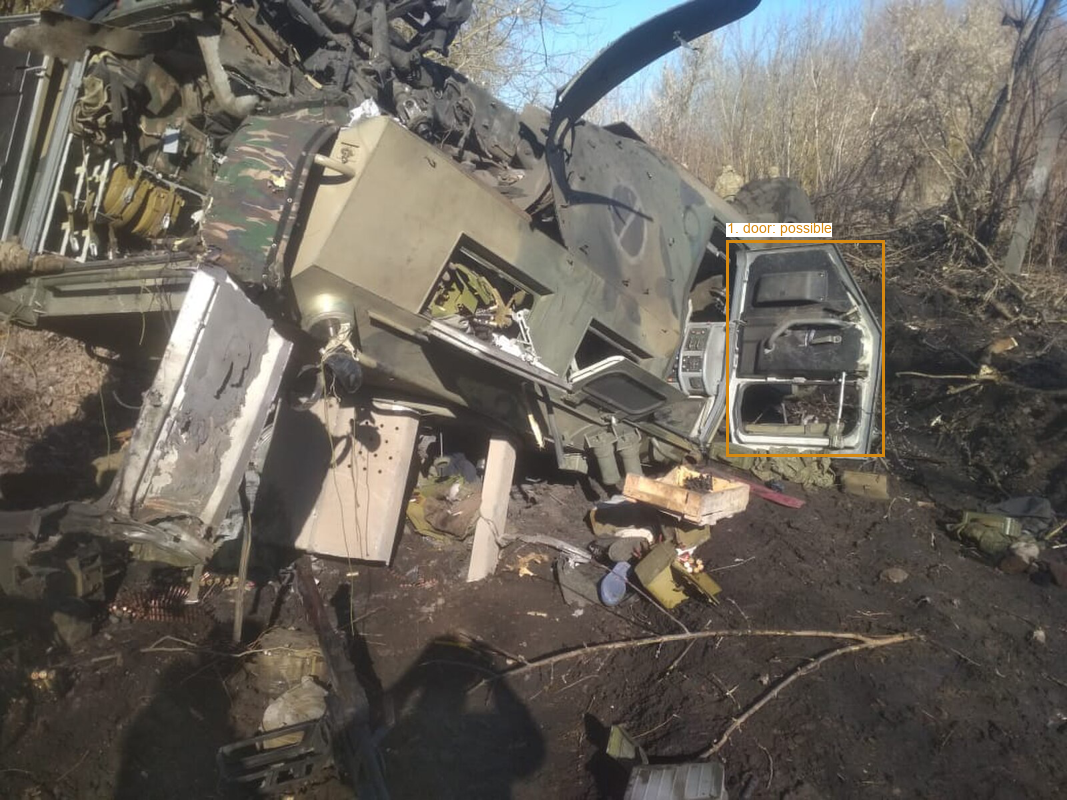

,part,damage,part score,damage score
box,,,,
1,door,possible_damage,0.938,0.995


commons_122203760.jpg — 4 detected parts


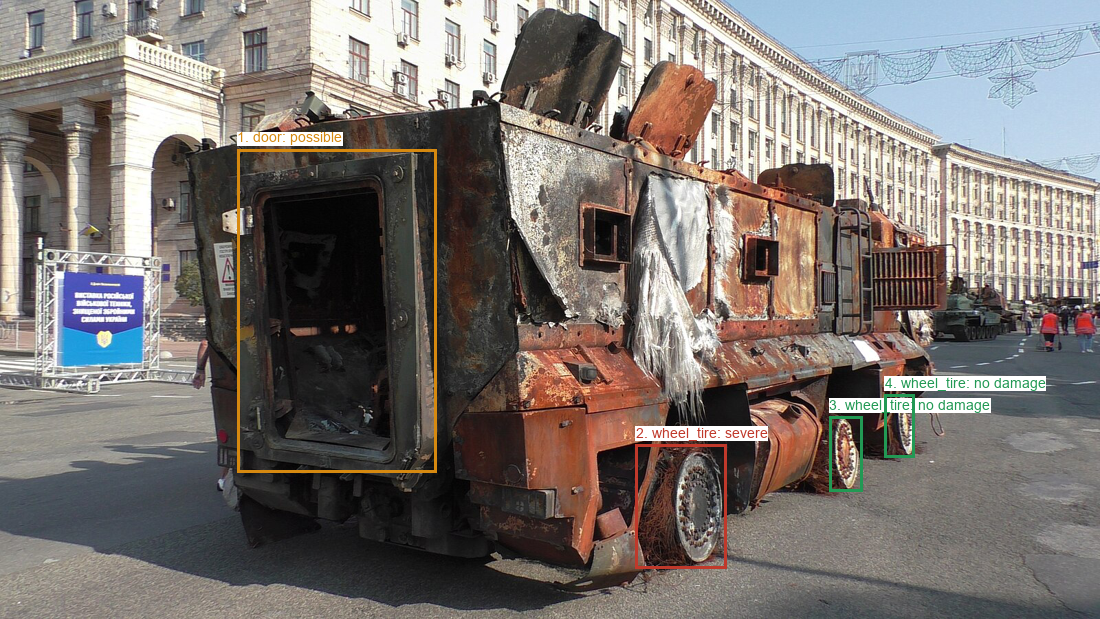

,part,damage,part score,damage score
box,,,,
1,door,possible_damage,0.939,0.746
2,wheel_tire,severe_visible_damage,0.887,0.603
3,wheel_tire,no_visible_damage,0.833,0.388
4,wheel_tire,no_visible_damage,0.570,0.402


In [7]:
@torch.inference_mode()
def show_prediction(image_path):
    with Image.open(image_path) as source:
        original = source.convert("RGB")
    raw_bgr = cv2.cvtColor(np.array(original), cv2.COLOR_RGB2BGR)
    ratio = min(exp.test_size[0] / original.height, exp.test_size[1] / original.width)
    network_input, _ = detector_transform(raw_bgr, None, exp.test_size)
    detections = postprocess(
        detector(torch.from_numpy(network_input).unsqueeze(0).float().to(DEVICE)),
        exp.num_classes, DETECTION_THRESHOLD, exp.nmsthre,
    )[0]
    preview = original.copy()
    preview.thumbnail((1100, 800))
    sx, sy = preview.width / original.width, preview.height / original.height
    draw, rows = ImageDraw.Draw(preview), []
    if detections is not None:
        for detection in detections.cpu():
            x1, y1, x2, y2 = (detection[:4] / ratio).tolist()
            box = (max(0, math.floor(x1)), max(0, math.floor(y1)),
                   min(original.width, math.ceil(x2)), min(original.height, math.ceil(y2)))
            if box[2] <= box[0] or box[3] <= box[1]:
                continue
            part = PARTS[int(detection[6])]
            group = PART_GROUPS[part]
            crop = damage_transforms[group](original.crop(box)).unsqueeze(0).to(DEVICE)
            probabilities = damage_models[group](crop).softmax(dim=1)[0]
            damage_index = int(probabilities.argmax())
            level = damage_levels[group][damage_index]
            number = len(rows) + 1
            rows.append({"box": number, "part": part, "damage": level,
                         "part score": round(float(detection[4] * detection[5]), 3),
                         "damage score": round(float(probabilities[damage_index]), 3)})
            screen_box = (box[0] * sx, box[1] * sy, box[2] * sx, box[3] * sy)
            color = COLORS[level]
            draw.rectangle(screen_box, outline=color, width=3)
            label = f"{number}. {part}: {SHORT_LABELS[level]}"
            text_width = draw.textbbox((0, 0), label, font=font)[2]
            position = (max(0, min(screen_box[0], preview.width - text_width - 4)),
                        max(0, screen_box[1] - 20))
            draw.rectangle(draw.textbbox(position, label, font=font), fill="white")
            draw.text(position, label, fill=color, font=font)
    print(f"{Path(image_path).name} — {len(rows)} detected parts")
    display(preview)
    if rows:
        display(pd.DataFrame(rows).set_index("box"))
    else:
        print("No parts exceeded the detection threshold.")
    return preview

for image_path in IMAGE_PATHS:
    show_prediction(image_path)